#  Wine classification model using k-NN (k-Nearest Neighbors)

#### Author 1
- **Name:** João Pedro Fernandes de Aquino
- **GitHub:** https://github.com/Joaof14

#### Author 2
- **Name:** Anderson Carlos da Silva Morais
- **GitHub:** https://github.com/AndersonCSM

## Project Summary

The wine industry has historically relied on human assessments—expensive, slow, and subjective. A predictive quality model has direct applications in batch control before bottling, pricing, and designation of origin certification by regulatory bodies. In oenological research (the science that studies the production, preservation, and analysis of wines), it also helps identify which chemical variables most influence the perception of quality, guiding production decisions. Platforms like Vivino (https://www.vivino.com/BR/pt-BR/) already use machine learning for this purpose. In Brazil, the context of the São Francisco Valley—the world's largest tropical wine hub, located here in the Northeast—makes the problem especially relevant and motivating for our reality. In this project, you are invited to build a wine classification model into three quality categories (low, medium, and high) from a set of chemical data using k-NN (k-Nearest Neighbors).



## Project Steps
1. Data exploration and quality checks;
2. Validate modeling assumptions;
3. Feature selection;
4. Normalization or scaling and Data split;
5. Model fitting (adjustment);
6. Assessment;
7. Coefficient or feature-importance analysis;
8. Residual/error analysis;
9.  Report.

## Step 1: Data Exploration and Quality Checks
#### Collecting evidence about the dataset before making modeling decisions.

The project uses the winequality-red.csv file from the [Wine Quality dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). The dataset was created by Paulo Cortez et al. (University of Minho, Portugal) and published in 2009. It includes 1,599 samples of red wine from the Vinho Verde region in northwest Portugal. Each sample was subjected to laboratory tests that generated 11 physicochemical attributes — such as fixed acidity, volatile acidity, citric acid content, residual sugar, chlorides, sulfur dioxide, density, pH, sulfates, and alcohol content. The quality label is an integer value from 0 to 10 assigned by sommeliers in blind evaluations, representing the median of at least three human evaluations.

For more information, read [Cortez et al., 2009].
Input variables (based on physicochemical tests):
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
   10. sulphates
   11. alcohol

Output variable (based on sensory data): 

   12. quality (score between 0 and 10)


Steps:

1. **Initial Inspection**
   * `df.info()`: check the number of rows and columns, and the data types (int, float, object).
   * `df.describe()`: obtain a quick statistical summary (mean, standard deviation, minimum, maximum, and quartiles).

2. **Data Quality Validation**
   * **Missing Values:** check whether missing data exist (`df.isnull().sum()`) and define a strategy (input using median for 'ca' and 'thal').
   * **Duplicate Data:** identify and remove identical readings that may distort the analysis (`df.duplicated().sum()`).
   * **Target Variable** Binarize the target variable: transform original values (0-4) to binary (0 = no disease, 1 = with disease);

3. **Univariate Analysis**
   * **Distribution:** plot histograms to understand how each sensor's data is distributed.
   * **Outlier Detection:** use boxplots to identify extreme values that deviate from the expected plant pattern.

4. **Bivariate and Multivariate Analysis**
   * **Correlation Matrix:** compute indices such as Pearson's correlation to quantify the strength of the relationship between variables.
   * **Visual Trends:** create box plots crossing the predictor variables with the target variable to validate hypotheses visually.For categorical predictors, stacked bar charts are used to show the proportion of the target across each category



In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
)

In [4]:
df = pd.read_csv("data/p03_winequality-red.csv", sep=";")

In [5]:
print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows of the dataset:")
df.head(10)

Dataset shape: (1599, 12)

First rows of the dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


### 1.0 Initial inspection

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

### 1.1 Separation into classes

In [8]:
df["target"] = pd.cut(
df["quality"],
bins=[0, 5, 7, 10],
labels=[0, 1, 2], # - O ruim, 1 - médio, 2 - bom
include_lowest=True
).astype(int)

df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'target'],
      dtype='object')

In [9]:
df = df.drop(columns=["quality"])
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='object')

In [10]:
X = df.drop(columns=["target"])
y = df["target"]

### 1.2 Balanceamento de Classes (Crítico para KNN)

Se a quantidade de amostras de grupo não for balanceada, um grupo pode sobrepor os demais para classificar as amostras.

In [11]:
# Verificar balanceamento do target
print("Balanceamento de classes (target):")
print(df["target"].value_counts().sort_index())
print("\nProporção (%):")
print(df["target"].value_counts(normalize=True).sort_index() * 100)

Balanceamento de classes (target):
target
0    744
1    837
2     18
Name: count, dtype: int64

Proporção (%):
target
0    46.529081
1    52.345216
2     1.125704
Name: proportion, dtype: float64


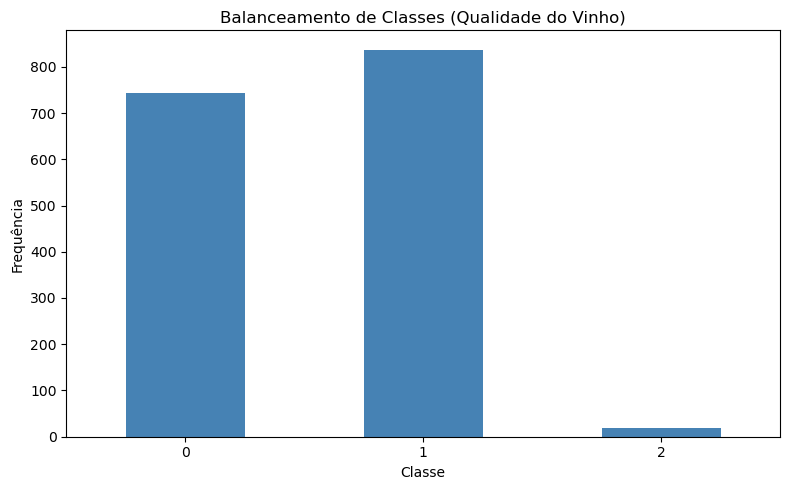

In [12]:
# Visualizar distribuição
fig, ax = plt.subplots(figsize=(8, 5))
df["target"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Balanceamento de Classes (Qualidade do Vinho)", fontsize=12)
ax.set_xlabel("Classe")
ax.set_ylabel("Frequência")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 1.3 Escala das Variáveis

Etapa essencial para auxiliar no processo de normalização. pois diferentes escalas entre variáveis -> Normalização OBRIGATÓRIA para KNN

Total de features numéricas: 11
Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


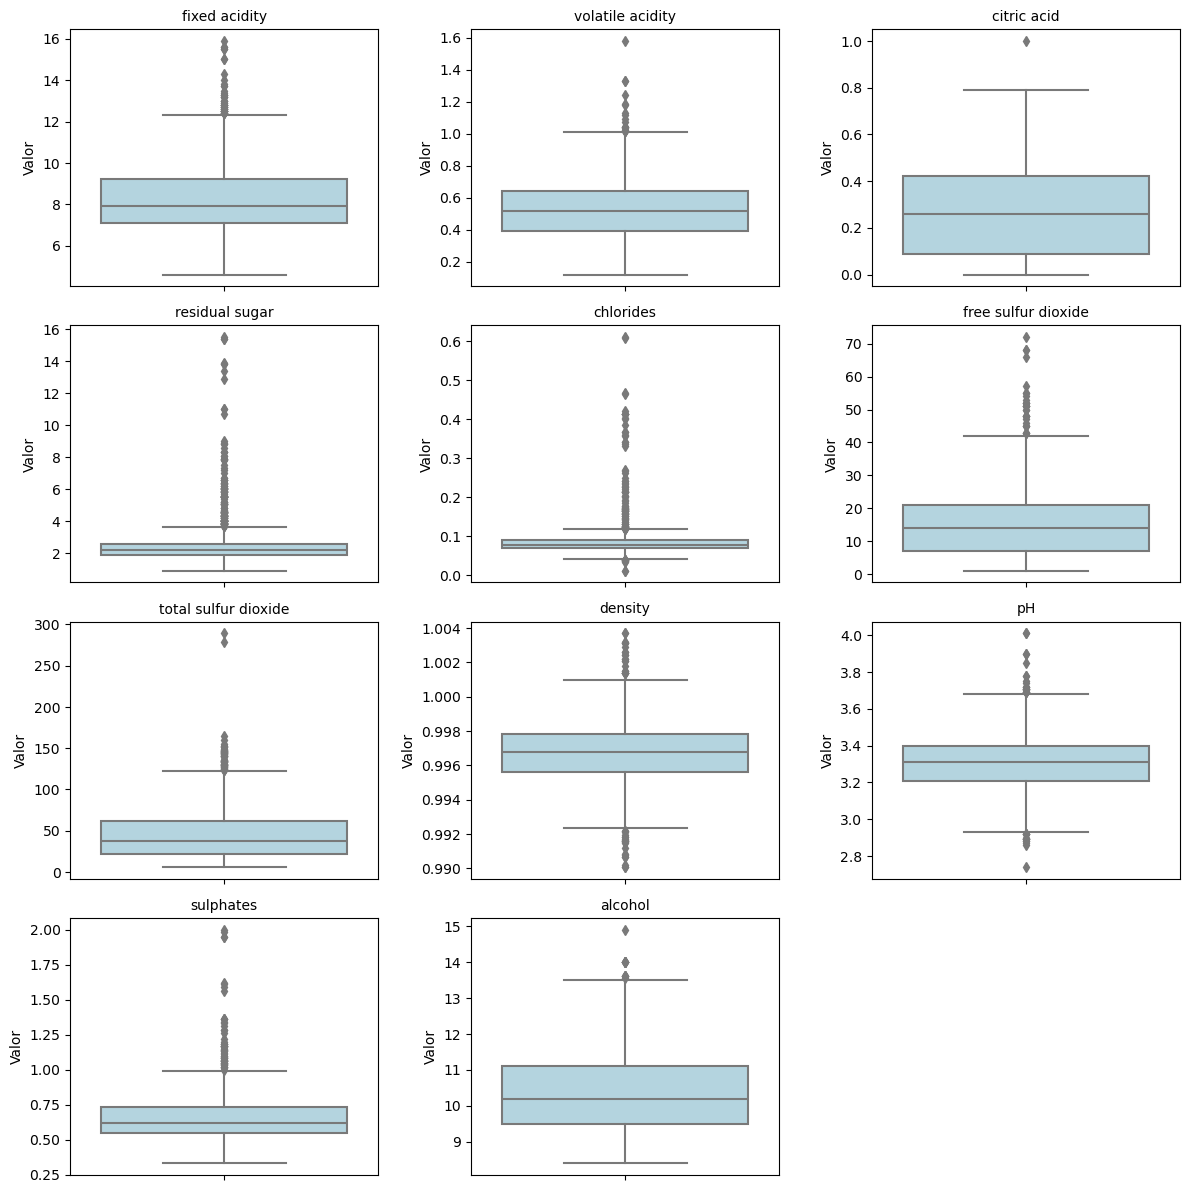

In [13]:
# Listar todas as colunas numéricas (excluindo quality e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["quality", "target"]]

print(f"Total de features numéricas: {len(numeric_cols)}")
print(f"Colunas: {numeric_cols}")

# Boxplots para ver escala - KNN é sensível a escala (grade dinâmica)
ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_ylabel("Valor")

# Remover subplots não utilizados
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 1.4 Detecção de Outliers (Afetam Distância no KNN)
 Outliers podem dominar distâncias -> Considere normalizar ou usar métrica ponderada

obs:
IQR = Interquartile Range (Amplitude Interquartil)

É a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1):

In [14]:
# Função para quantificar outliers usando IQR
def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), (lower, upper)

print("Quantificação de Outliers (IQR 1.5x):\n")
outlier_summary = []
for col in numeric_cols:
    count, (lower, upper) = count_outliers_iqr(df, col)
    pct = (count / len(df)) * 100
    outlier_summary.append({"Feature": col, "Outliers": count, "Percentual": f"{pct:.2f}%"})
    print(f"{col:20s}: {count:3d} outliers ({pct:.2f}%)")

df_outliers = pd.DataFrame(outlier_summary)

Quantificação de Outliers (IQR 1.5x):

fixed acidity       :  49 outliers (3.06%)
volatile acidity    :  19 outliers (1.19%)
citric acid         :   1 outliers (0.06%)
residual sugar      : 155 outliers (9.69%)
chlorides           : 112 outliers (7.00%)
free sulfur dioxide :  30 outliers (1.88%)
total sulfur dioxide:  55 outliers (3.44%)
density             :  45 outliers (2.81%)
pH                  :  35 outliers (2.19%)
sulphates           :  59 outliers (3.69%)
alcohol             :  13 outliers (0.81%)


### 1.5 Matriz de Correlação

Objetivo: detectar redundância nas features.

Correlação de cada feature com o target (qualidade):

alcohol                 0.450986
sulphates               0.223183
citric acid             0.165994
fixed acidity           0.094288
residual sugar         -0.001474
pH                     -0.009287
free sulfur dioxide    -0.064615
chlorides              -0.113781
density                -0.170227
total sulfur dioxide   -0.231076
volatile acidity       -0.320968
Name: target, dtype: float64


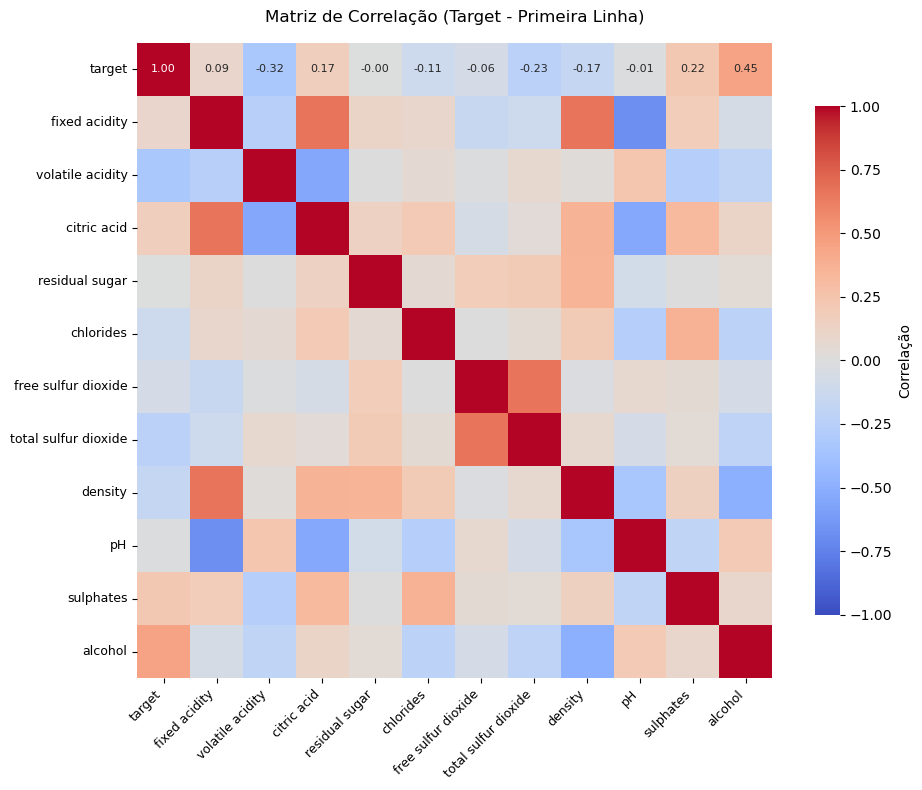

  Nenhuma redundância detectada (correlação > 0.7)


In [15]:
# Calcular correlação com o target
corr_matrix = df[numeric_cols + ["target"]].corr()

# Extrair a linha target nas colunas numeric_cols (garante Series)
corr_with_target = corr_matrix.loc["target", numeric_cols]

# Ordenar
corr_with_target = corr_with_target.sort_values(ascending=False)

print("Correlação de cada feature com o target (qualidade):\n")
print(corr_with_target)

# Heatmap com target na primeira linha - Versão minimalista
# Reordenar: target primeiro, depois as demais colunas
cols_reordered = ["target"] + numeric_cols
corr_matrix = corr_matrix.reindex(cols_reordered)[cols_reordered]

fig, ax = plt.subplots(figsize=(10, 8))

# Minimalista: sem bordas, sem elementos visuais desnecessários
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            center=0, 
            linewidths=0,
            vmin=-1, 
            vmax=1, 
            ax=ax,
            cbar_kws={"label": "Correlação", "shrink": 0.8},
            square=True,
            annot_kws={"size": 8})

ax.set_title("Matriz de Correlação (Target - Primeira Linha)", fontsize=12, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# Detectar features muito correlacionadas (redundância)
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr_val = corr_matrix.iloc[i+1, j+1]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_val))
            print(f"  {numeric_cols[i]:20s} <-> {numeric_cols[j]:20s}: {corr_val:.3f}")

if not high_corr_pairs:
    print("  Nenhuma redundância detectada (correlação > 0.7)")

### 1.6 Visual Trends - Distribuição por Classe (Separabilidade para KNN)

Top 6 features com maior correlação com qualidade:
alcohol                 0.450986
volatile acidity       -0.320968
total sulfur dioxide   -0.231076
sulphates               0.223183
density                -0.170227
citric acid             0.165994
Name: target, dtype: float64


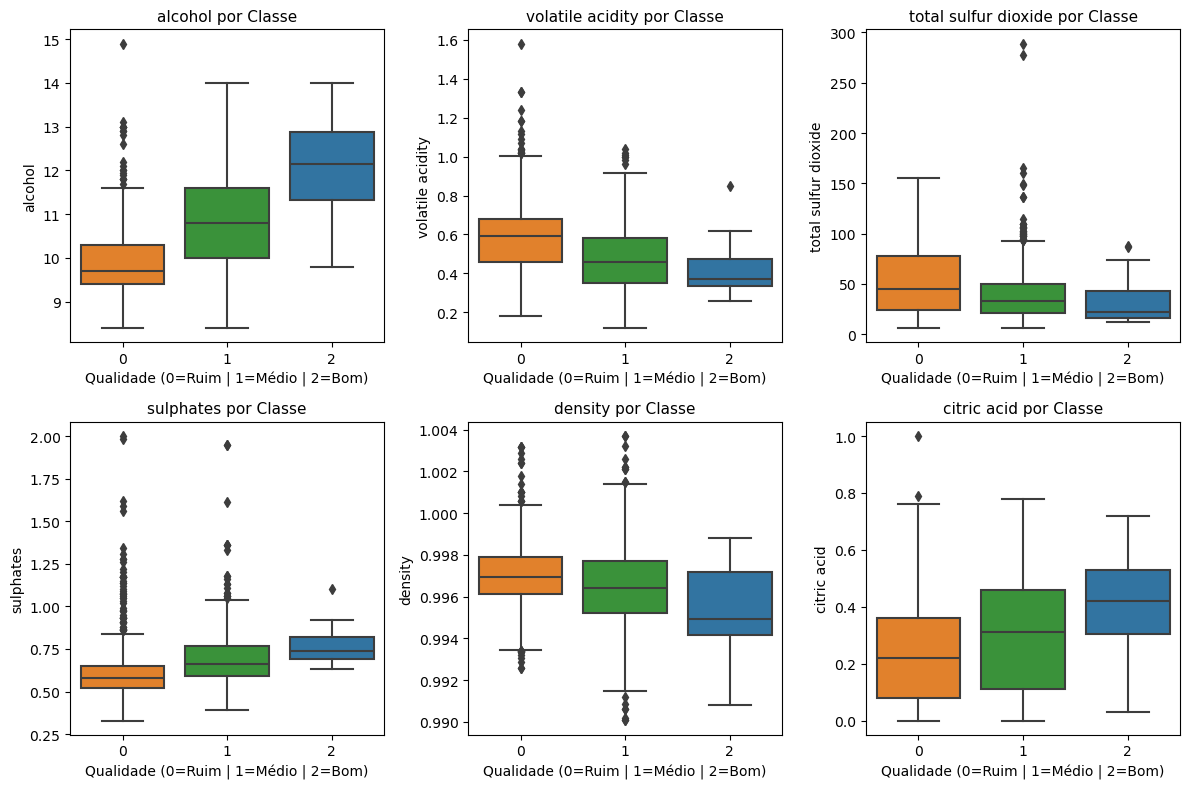


✓ Se há boa separação entre boxplots, KNN terá melhor desempenho


In [16]:
# Selecionar features com maior correlação com o target para visualização
top_features = corr_with_target.abs().nlargest(6).index.tolist()

print(f"Top 6 features com maior correlação com qualidade:")
print(corr_with_target[top_features])

# Boxplots cruzados
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Palette com valores em string (seaborn espera string quando x é categórico)
palette = {"0": "#ff7f0e", "1": "#2ca02c", "2": "#1f77b4"}

for i, feat in enumerate(top_features):
    # Converter target para string para compatibilidade com paleta
    sns.boxplot(x=df["target"].astype(str), y=df[feat], ax=axes[i], palette=palette)
    axes[i].set_title(f"{feat} por Classe", fontsize=11)
    axes[i].set_xlabel("Qualidade (0=Ruim | 1=Médio | 2=Bom)")
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.show()

print("\n✓ Se há boa separação entre boxplots, KNN terá melhor desempenho")

### 1.7 Resumo data explorer
1. BALANCEAMENTO DE CLASSES:

   Ruim: 46.5% | Médio: 52.3% | Bom: 1.1%
   Classes desbalanceadas -> utilizar stratify no train_test_split

2. ESCALA DAS VARIÁVEIS:

   11 features numéricas com escalas diferentes
   NORMALIZAÇÃO OBRIGATÓRIA -> StandardScaler ou MinMaxScaler

3. OUTLIERS:

   Total: 573 outliers em 11 features
   Percentual médio: 3.26%
   Outliers significativos -> normalizar reduz impacto

4. REDUNDÂNCIA DE FEATURES:

   Nenhuma redundância detectada

5. TOP 3 FEATURES MAIS CORRELACIONADAS COM QUALIDADE:
   1. alcohol: 0.451
   2. sulphates: 0.223
   3. citric acid: 0.166

6. PRÓXIMOS PASSOS:
   1. Normalizar features (StandardScaler)
   2. Dividir treino/teste com stratify
   3. Testar k=1,3,5,7,11... com validação cruzada
   4. Escolher melhor k por acurácia média
   5. Avaliar no conjunto teste (matriz confusão, F1-score)

## Step 2: Validate Modeling Assumptions


## Step 3: Feature Selection


## Step 4 and 5: Normalization or Scaling and Data Split


## Step 6: Model Fitting (Adjustment)
Train the selected model with the prepared dataset.


## Step 7: Assessment
Measure how well the model predicts unseen data.


## Step 8: Coefficient or Feature-Importance Analysis
Explain how each variable affects the prediction.


## Step 9: Residual/Error Analysis
Check whether the prediction errors are well-behaved.


## Step 10: Report




1. **Preparação dos dados:** carregue o dataset e recodifique a variável quality em três classes: notas ≤ 5 como
ruim, 6–7 como médio e ≥ 8 como bom. Em seguida, normalize todos os atributos utilizando Min-Max ou
Z-score. Justifique por que a normalização é uma etapa obrigatória para o 𝑘-NN.

2. **Divisão treino/teste:** divida os dados em 80% para treino e 20% para teste, utilizando divisão estratificada
para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

3. **Treinamento e escolha do 𝑘:** treine o modelo para diferentes valores de 𝑘 (ex: 1, 3, 5, 7, 11) utilizando
validação cruzada de 5 folds sobre o conjunto de treino. Plote a acurácia média em função de 𝑘 e escolha
o valor com melhor desempenho. O que acontece com o modelo para valores muito baixos e muito altos
de 𝑘?

4. **Avaliação do modelo:** utilizando o conjunto de teste — reservado exclusivamente para esta etapa — calcule
a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe. Responda:
Entre quais classes o modelo erra com mais frequência?

#### 10.4 Avaliação do Modelo Final